In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

2026-05-08 08:48:56.033290: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778230136.310835      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778230136.389384      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778230137.081107      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778230137.081150      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778230137.081153      57 computation_placer.cc:177] computation placer alr


--- Training with SGD ---

--- Training with ADAM ---


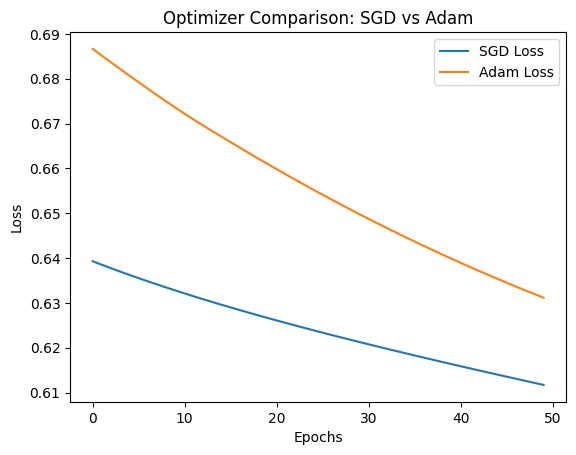


Conclusion: Adam typically reaches lower loss faster than SGD.


In [1]:
# --- Day 12: SGD vs Adam Optimizer Experiment ---
# Goal: Compare how different optimizers affect model learning.

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# 1. Dummy Data (Scaling apply ki hai taake training fast ho)
X = np.array([[1.0], [2.0], [3.0], [4.0]], dtype=float)
y = np.array([[0], [0], [1], [1]], dtype=float)

# 2. Function to build and train model with a specific optimizer
def train_with_optimizer(opt_name):
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(8, activation='relu', input_dim=1),
        tf.keras.layers.Dense(1, activation='sigmoid')
    ])
    
    model.compile(optimizer=opt_name, loss='binary_crossentropy', metrics=['accuracy'])
    
    print(f"\n--- Training with {opt_name.upper()} ---")
    history = model.fit(X, y, epochs=50, verbose=0) # verbose=0 taake output saaf rahe
    return history.history['loss']

# 3. Experiment shuru karte hain
loss_sgd = train_with_optimizer('sgd')
loss_adam = train_with_optimizer('adam')

# 4. Results Visualization (Professional Touch!)
plt.plot(loss_sgd, label='SGD Loss')
plt.plot(loss_adam, label='Adam Loss')
plt.title('Optimizer Comparison: SGD vs Adam')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

print("\nConclusion: Adam typically reaches lower loss faster than SGD.")